<a href="https://colab.research.google.com/github/reshmabegumnasser/sales-forecasting-ml/blob/main/notebooks/01_sales_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("GitHub connection test")

GitHub connection test


In [2]:
import pandas as pd

file_path = '/content/sales_forecasting_master_dataset 2.xlsx'
df = pd.read_excel(file_path)

In [3]:
display(df.head())

,Row_ID,Date,Product_ID,Product_Name,Category,Store_ID,Store_Location,Units_Sold,Price,Discount_Percentage,...,Holiday_Name,Is_Weekend,Season,Weather,Local_Event_Flag,Competitor_Price,Economic_Indicator,Sales_Channel,Customer_Segment,Marketing_Spend
0,1,2024-01-01,P002,Bluetooth Speaker,Electronics,S01,Chennai,58,3759.44,0,...,New Year,0,Winter,Sunny,1,3448.86,101.33,Online,Retail,109.32
1,2,2024-01-02,P001,Wireless Mouse,Electronics,S02,Bengaluru,0,3636.89,15,...,NaN,0,Winter,Stormy,0,3599.95,99.17,Online,Retail,7132.32
2,3,2024-01-03,P006,Running Shoes,Apparel,S03,Mumbai,91,946.30,20,...,NaN,0,Winter,Sunny,0,923.58,100.38,In-Store,Wholesale,3012.95
3,4,2024-01-04,P001,Wireless Mouse,Electronics,S04,Delhi,57,2773.89,5,...,NaN,0,Winter,Clear,0,2956.64,104.28,In-Store,Wholesale,2326.74
4,5,2024-01-05,P002,Bluetooth Speaker,Electronics,S01,Chennai,59,3374.06,20,...,NaN,0,Winter,Sunny,0,3621.37,100.70,In-Store,Wholesale,8424.05


In [4]:
!pip install statsmodels

In [5]:
!pip install prophet

In [6]:
!pip install tensorflow

In [7]:
!pip install xgboost

In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from xgboost import XGBRegressor

from prophet import Prophet

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import joblib

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [11]:
from google.colab import files

uploaded = files.upload()

Saving sales_forecasting_master_dataset 2.xlsx to sales_forecasting_master_dataset 2 (1).xlsx


In [12]:
file_name = list(uploaded.keys())[0]

df = pd.read_excel(
    file_name,
    sheet_name="Sales_Data"
)

print("Shape:", df.shape)
df.head()

Shape: (730, 27)


,Row_ID,Date,Product_ID,Product_Name,Category,Store_ID,Store_Location,Units_Sold,Price,Discount_Percentage,...,Holiday_Name,Is_Weekend,Season,Weather,Local_Event_Flag,Competitor_Price,Economic_Indicator,Sales_Channel,Customer_Segment,Marketing_Spend
0,1,2024-01-01,P002,Bluetooth Speaker,Electronics,S01,Chennai,58,3759.44,0,...,New Year,0,Winter,Sunny,1,3448.86,101.33,Online,Retail,109.32
1,2,2024-01-02,P001,Wireless Mouse,Electronics,S02,Bengaluru,0,3636.89,15,...,NaN,0,Winter,Stormy,0,3599.95,99.17,Online,Retail,7132.32
2,3,2024-01-03,P006,Running Shoes,Apparel,S03,Mumbai,91,946.30,20,...,NaN,0,Winter,Sunny,0,923.58,100.38,In-Store,Wholesale,3012.95
3,4,2024-01-04,P001,Wireless Mouse,Electronics,S04,Delhi,57,2773.89,5,...,NaN,0,Winter,Clear,0,2956.64,104.28,In-Store,Wholesale,2326.74
4,5,2024-01-05,P002,Bluetooth Speaker,Electronics,S01,Chennai,59,3374.06,20,...,NaN,0,Winter,Sunny,0,3621.37,100.70,In-Store,Wholesale,8424.05


In [13]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

Rows: 730
Columns: 27

Column names:
['Row_ID', 'Date', 'Product_ID', 'Product_Name', 'Category', 'Store_ID', 'Store_Location', 'Units_Sold', 'Price', 'Discount_Percentage', 'Revenue', 'Promotion_Flag', 'Stock_Availability', 'Day_of_Week', 'Month', 'Quarter', 'Holiday_Flag', 'Holiday_Name', 'Is_Weekend', 'Season', 'Weather', 'Local_Event_Flag', 'Competitor_Price', 'Economic_Indicator', 'Sales_Channel', 'Customer_Segment', 'Marketing_Spend']

Data types:
Row_ID                   int64
Date                    object
Product_ID              object
Product_Name            object
Category                object
Store_ID                object
Store_Location          object
Units_Sold               int64
Price                  float64
Discount_Percentage      int64
Revenue                float64
Promotion_Flag           int64
Stock_Availability       int64
Day_of_Week             object
Month                   object
Quarter                 object
Holiday_Flag             int64
Holiday_Name   

In [14]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

print(df["Date"].min())
print(df["Date"].max())

2024-01-01 00:00:00
2025-12-30 00:00:00


In [15]:
full_dates = pd.date_range(
    start=df["Date"].min(),
    end=df["Date"].max(),
    freq="D"
)

missing_dates = full_dates.difference(df["Date"])

print("Missing dates:", len(missing_dates))

if len(missing_dates) > 0:
    print(missing_dates)

Missing dates: 0


In [16]:
TARGET = "Units_Sold"

print(df[TARGET].describe())

count    730.000000
mean      42.153425
std       29.115559
min        0.000000
25%       16.000000
50%       44.000000
75%       64.000000
max      118.000000
Name: Units_Sold, dtype: float64


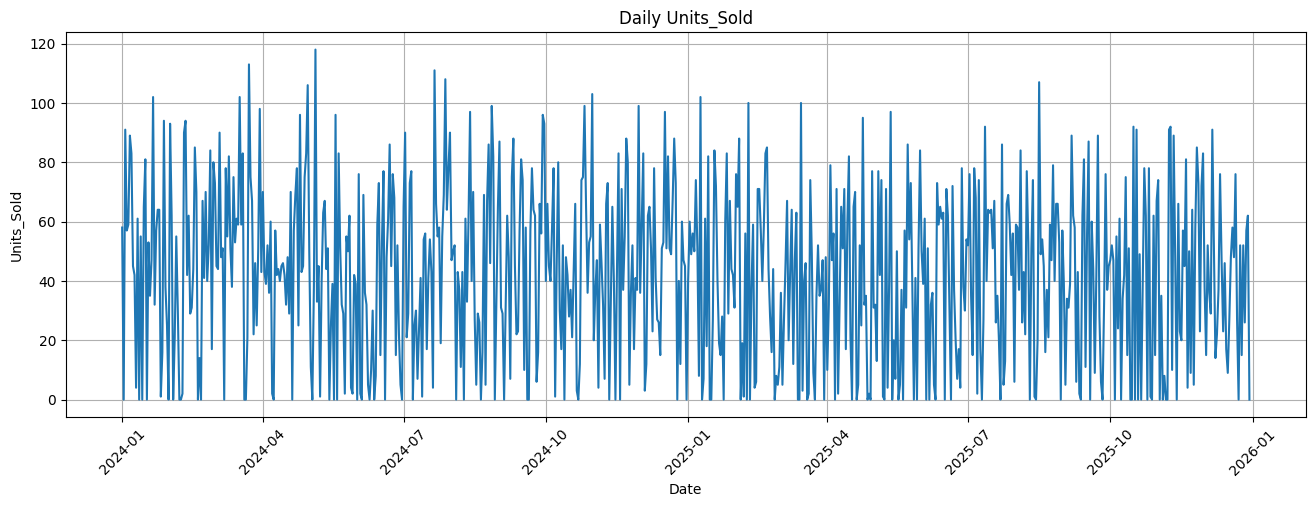

In [17]:
plt.figure(figsize=(16, 5))

plt.plot(
    df["Date"],
    df[TARGET]
)

plt.title(f"Daily {TARGET}")
plt.xlabel("Date")
plt.ylabel(TARGET)

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

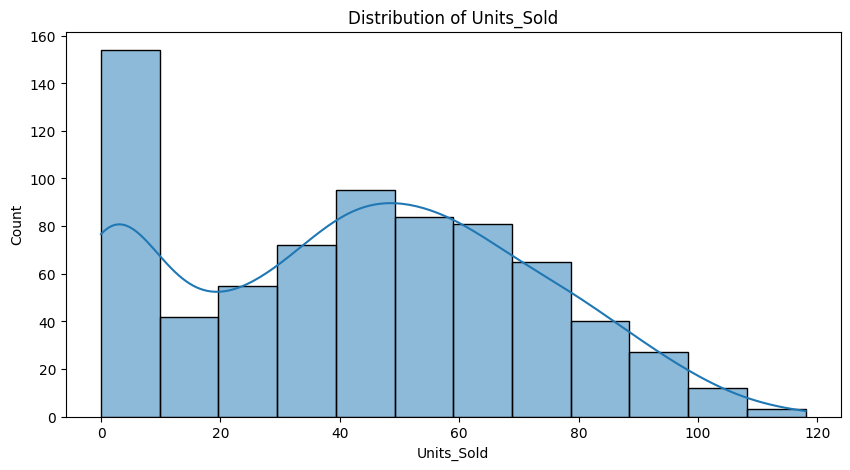

In [18]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df[TARGET],
    kde=True
)

plt.title(f"Distribution of {TARGET}")

plt.show()

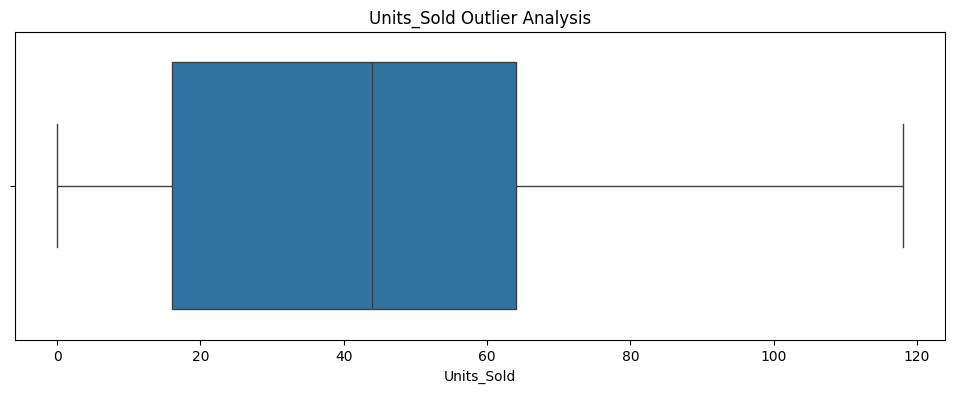

In [19]:
plt.figure(figsize=(12, 4))

sns.boxplot(
    x=df[TARGET]
)

plt.title(f"{TARGET} Outlier Analysis")

plt.show()

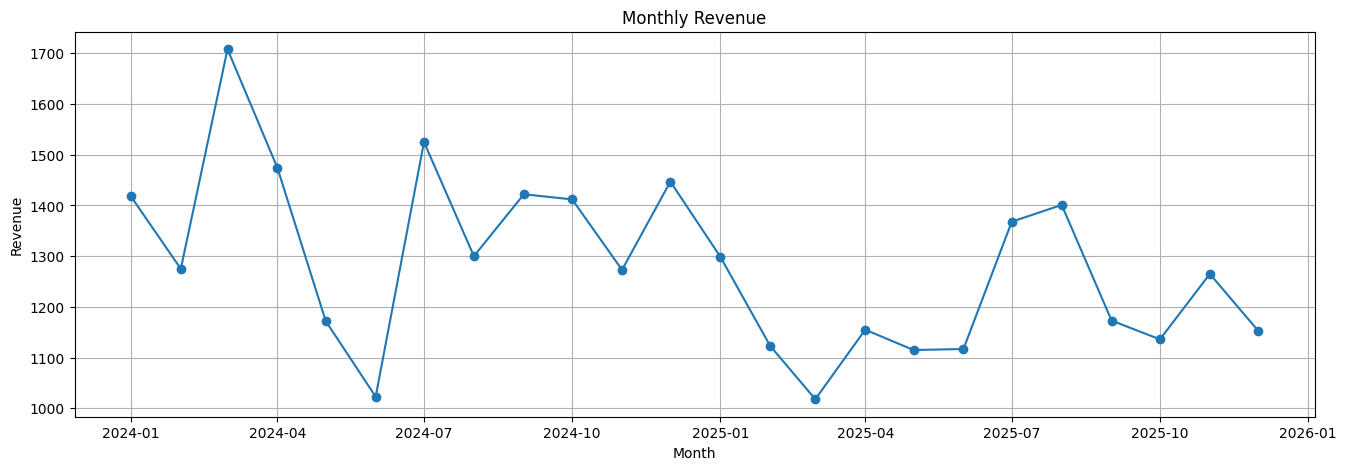

In [20]:
monthly_sales = (
    df.set_index("Date")[TARGET]
    .resample("MS")
    .sum()
)

plt.figure(figsize=(16, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Revenue")

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

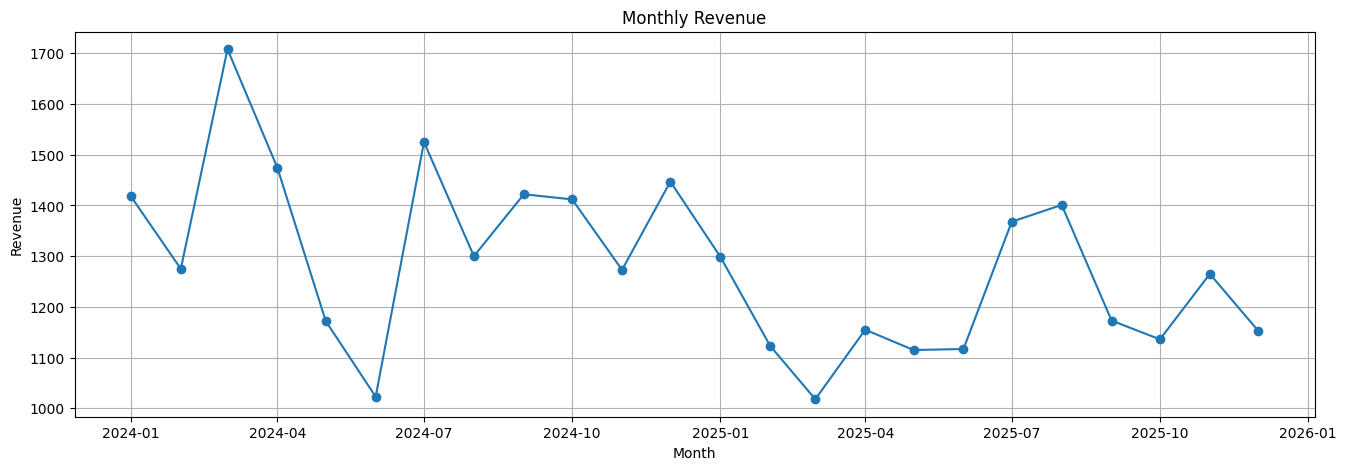

In [21]:
monthly_sales = (
    df.set_index("Date")[TARGET]
    .resample("MS")
    .sum()
)

plt.figure(figsize=(16, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Revenue")

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

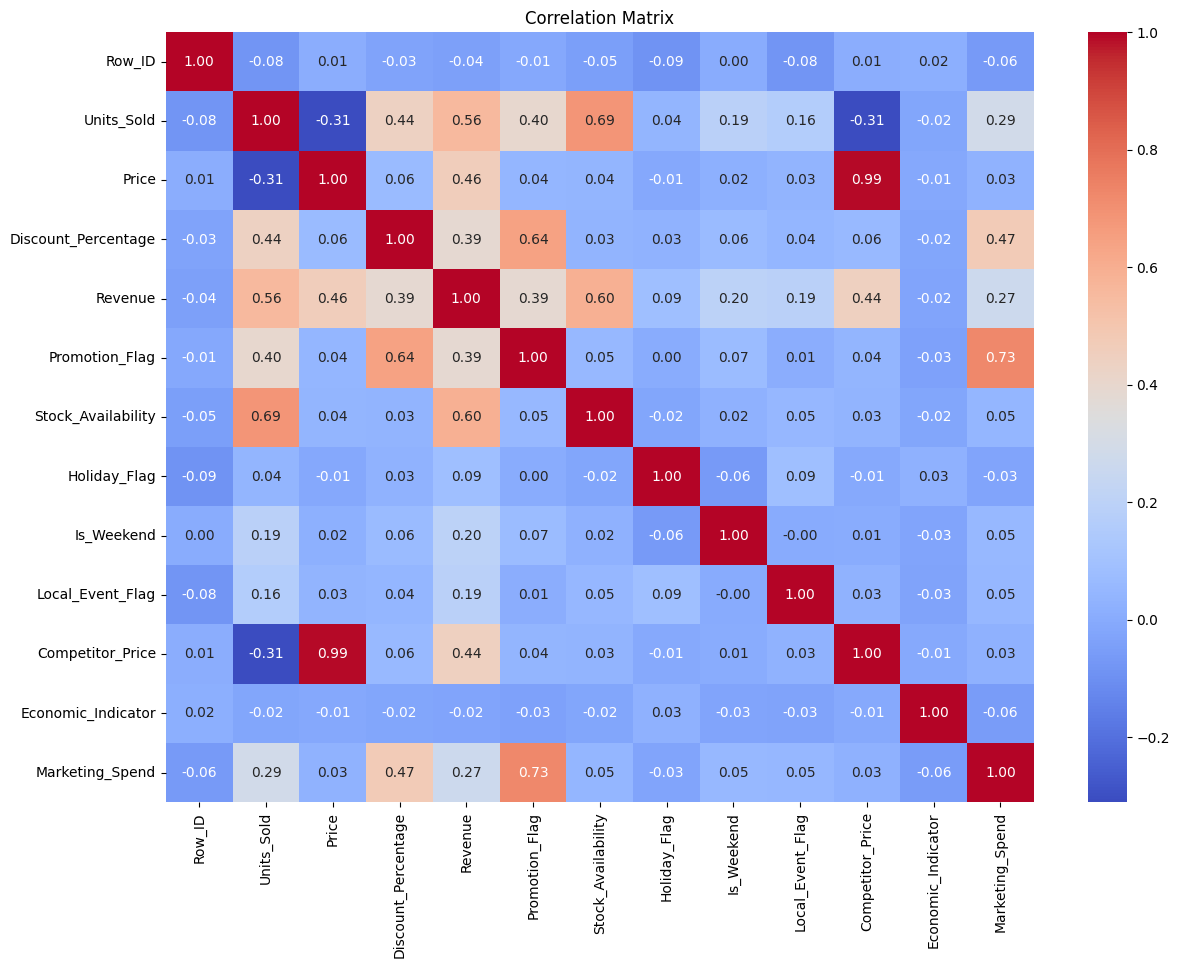

In [22]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

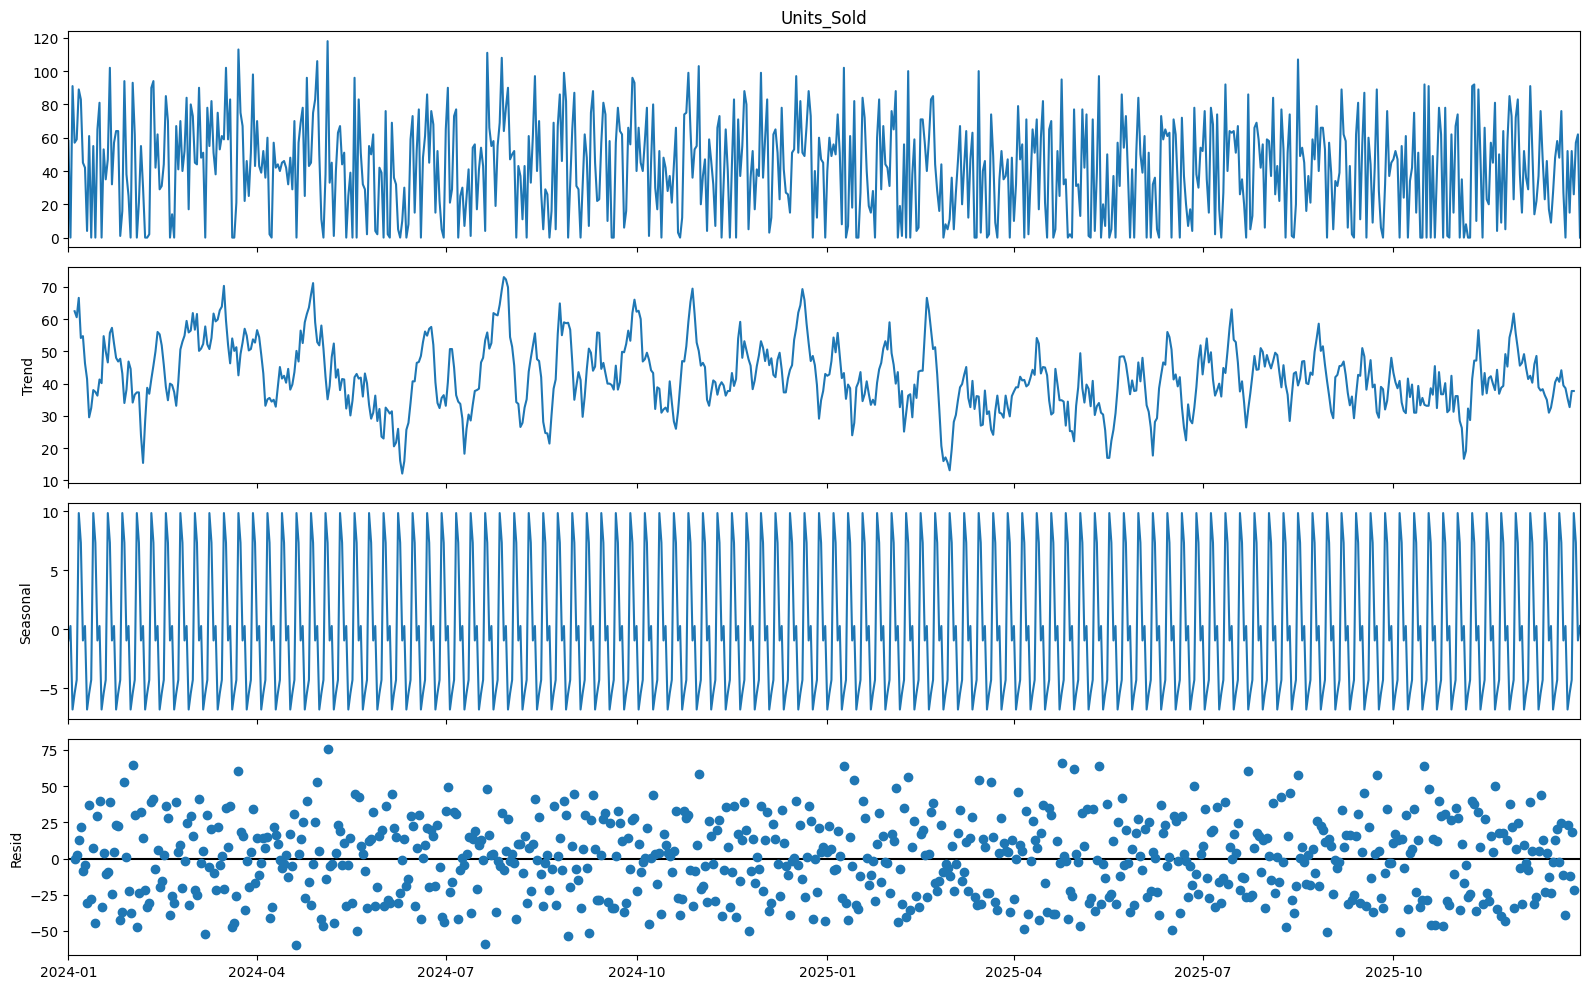

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

ts = df.set_index("Date")[TARGET]

decomposition = seasonal_decompose(
    ts,
    model="additive",
    period=7
)

# Set the figure size before plotting
plt.rcParams['figure.figsize'] = (16, 10)
decomposition.plot()

plt.show()

In [26]:
result = adfuller(ts.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is stationary")
else:
    print("Series is not stationary")

ADF Statistic: -20.005803688032582
p-value: 0.0
Series is stationary


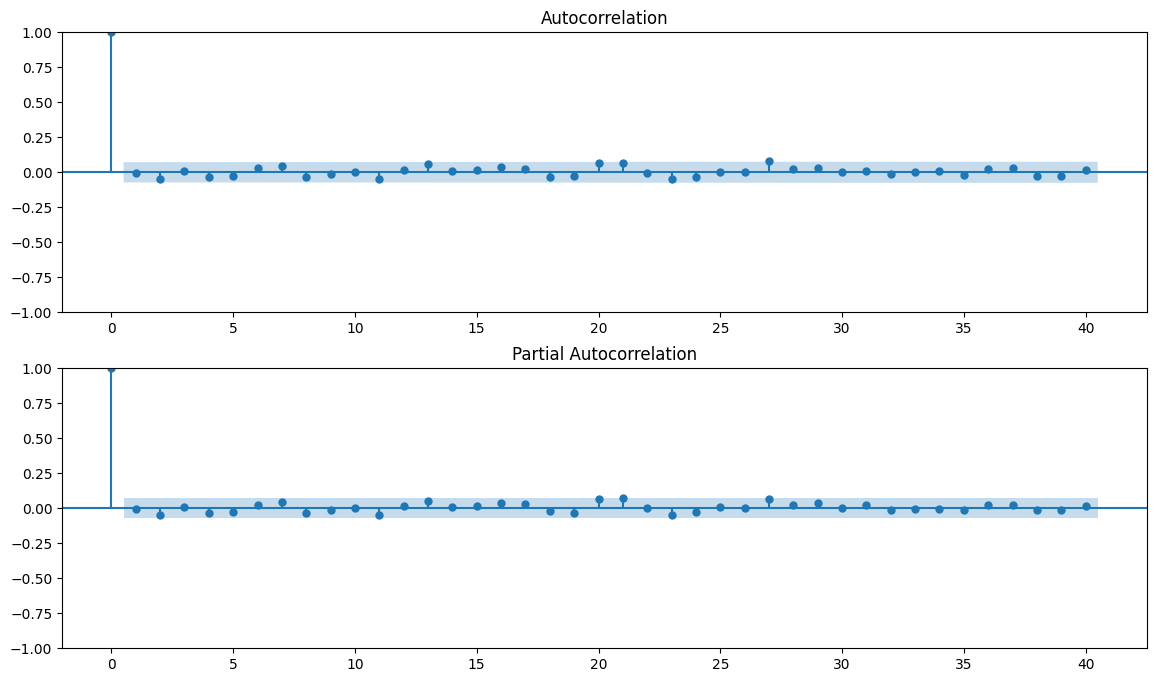

In [27]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8)
)

plot_acf(
    ts.dropna(),
    lags=40,
    ax=axes[0]
)

plot_pacf(
    ts.dropna(),
    lags=40,
    ax=axes[1],
    method="ywm"
)

plt.show()

In [28]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = df.iloc[:train_end].copy()
val = df.iloc[train_end:val_end].copy()
test = df.iloc[val_end:].copy()

print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

print("\nTrain:")
print(train["Date"].min(), "→", train["Date"].max())

print("\nValidation:")
print(val["Date"].min(), "→", val["Date"].max())

print("\nTest:")
print(test["Date"].min(), "→", test["Date"].max())

Train: (510, 27)
Validation: (110, 27)
Test: (110, 27)

Train:
2024-01-01 00:00:00 → 2025-05-24 00:00:00

Validation:
2025-05-25 00:00:00 → 2025-09-11 00:00:00

Test:
2025-09-12 00:00:00 → 2025-12-30 00:00:00


In [29]:
def create_time_features(data, target="Revenue"):

    df_feat = data.copy()

    df_feat["Date"] = pd.to_datetime(df_feat["Date"])

    # Calendar features
    df_feat["Year"] = df_feat["Date"].dt.year
    df_feat["Month_Num"] = df_feat["Date"].dt.month
    df_feat["Day"] = df_feat["Date"].dt.day
    df_feat["Day_of_Year"] = df_feat["Date"].dt.dayofyear
    df_feat["Week_of_Year"] = df_feat["Date"].dt.isocalendar().week.astype(int)

    df_feat["Day_Num"] = df_feat["Date"].dt.dayofweek

    df_feat["Is_Weekend_Calc"] = (
        df_feat["Day_Num"] >= 5
    ).astype(int)

    # Lag features
    for lag in [1, 2, 3, 7, 14, 21, 28]:
        df_feat[f"{target}_Lag_{lag}"] = (
            df_feat[target].shift(lag)
        )

    # Rolling features
    for window in [7, 14, 28]:

        df_feat[f"{target}_RollingMean_{window}"] = (
            df_feat[target]
            .shift(1)
            .rolling(window)
            .mean()
        )

        df_feat[f"{target}_RollingStd_{window}"] = (
            df_feat[target]
            .shift(1)
            .rolling(window)
            .std()
        )

    # Exponential moving averages
    df_feat[f"{target}_EMA_7"] = (
        df_feat[target]
        .shift(1)
        .ewm(span=7, adjust=False)
        .mean()
    )

    df_feat[f"{target}_EMA_28"] = (
        df_feat[target]
        .shift(1)
        .ewm(span=28, adjust=False)
        .mean()
    )

    return df_feat

In [30]:
df_ml = create_time_features(
    df,
    TARGET
)

print(df_ml.shape)

df_ml.head(35)

(730, 49)


,Row_ID,Date,Product_ID,Product_Name,Category,Store_ID,Store_Location,Units_Sold,Price,Discount_Percentage,...,Units_Sold_Lag_21,Units_Sold_Lag_28,Units_Sold_RollingMean_7,Units_Sold_RollingStd_7,Units_Sold_RollingMean_14,Units_Sold_RollingStd_14,Units_Sold_RollingMean_28,Units_Sold_RollingStd_28,Units_Sold_EMA_7,Units_Sold_EMA_28
0,1,2024-01-01,P002,Bluetooth Speaker,Electronics,S01,Chennai,58,3759.44,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2024-01-02,P001,Wireless Mouse,Electronics,S02,Bengaluru,0,3636.89,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.000000,58.000000
2,3,2024-01-03,P006,Running Shoes,Apparel,S03,Mumbai,91,946.30,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.500000,54.000000
3,4,2024-01-04,P001,Wireless Mouse,Electronics,S04,Delhi,57,2773.89,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.375000,56.551724
4,5,2024-01-05,P002,Bluetooth Speaker,Electronics,S01,Chennai,59,3374.06,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.781250,56.582640
5,6,2024-01-06,P003,Office Chair,Furniture,S03,Mumbai,89,1905.30,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56.585938,56.749354
6,7,2024-01-07,P005,LED Desk Lamp,Home,S02,Bengaluru,83,3486.15,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.689453,58.973537
7,8,2024-01-08,P006,Running Shoes,Apparel,S02,Bengaluru,45,3346.11,5,...,NaN,NaN,62.428571,31.368015,NaN,NaN,NaN,NaN,69.267090,60.630534
8,9,2024-01-09,P007,Yoga Mat,Sports,S04,Delhi,42,1937.58,0,...,NaN,NaN,60.571429,32.051298,NaN,NaN,NaN,NaN,63.200317,59.552566
9,10,2024-01-10,P007,Yoga Mat,Sports,S04,Delhi,4,3060.26,5,...,NaN,NaN,66.571429,20.767420,NaN,NaN,NaN,NaN,57.900238,58.342044


In [31]:
df_ml = df_ml.dropna().reset_index(drop=True)

print(df_ml.shape)

(5, 49)


In [32]:
categorical_cols = [
    "Category",
    "Store_Location",
    "Sales_Channel",
    "Customer_Segment",
    "Weather",
    "Season"
]

df_ml = pd.get_dummies(
    df_ml,
    columns=categorical_cols,
    drop_first=True
)

print(df_ml.shape)

(5, 56)


In [33]:
drop_cols = [
    "Row_ID",
    "Date",
    TARGET,
    "Product_ID",
    "Product_Name",
    "Store_ID",
    "Day_of_Week",
    "Month",
    "Quarter",
    "Holiday_Name"
]

drop_cols = [
    c for c in drop_cols
    if c in df_ml.columns
]

X = df_ml.drop(columns=drop_cols)

y = df_ml[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5, 46)
y shape: (5,)


In [34]:
n = len(df_ml)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
X_test = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val = y.iloc[train_end:val_end]
y_test = y.iloc[val_end:]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(3, 46)
(1, 46)
(1, 46)


In [35]:
n = len(df_ml)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
X_test = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val = y.iloc[train_end:val_end]
y_test = y.iloc[val_end:]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(3, 46)
(1, 46)
(1, 46)


In [37]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    metrics = {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }
    return pd.DataFrame([metrics])

train_ts = train.set_index("Date")[TARGET]
val_ts = val.set_index("Date")[TARGET]

arima_model = ARIMA(
    train_ts,
    order=(1, 1, 1)
)

arima_fit = arima_model.fit()

arima_val_pred = arima_fit.forecast(
    steps=len(val_ts)
)

arima_val_metrics = evaluate_model(
    val_ts,
    arima_val_pred,
    "ARIMA"
)

arima_val_metrics

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


,Model,MAE,MSE,RMSE,R2
0,ARIMA,23.028248,737.930747,27.164881,-0.014184


In [39]:
import itertools

p_values = [0, 1, 2, 3]
d_values = [0, 1]
q_values = [0, 1, 2, 3]

arima_results = []

for p, d, q in itertools.product(
    p_values,
    d_values,
    q_values
):

    try:

        model = ARIMA(
            train_ts,
            order=(p, d, q)
        )

        fitted = model.fit()

        pred = fitted.forecast(
            steps=len(val_ts)
        )

        # evaluate_model returns a single-row DataFrame. Convert it to a dictionary.
        model_metrics_df = evaluate_model(
            val_ts,
            pred,
            f"ARIMA({p},{d},{q})"
        )

        # Extract the dictionary from the single-row DataFrame
        model_metrics_dict = model_metrics_df.iloc[0].to_dict()

        # Add AIC to the dictionary
        model_metrics_dict["AIC"] = fitted.aic

        arima_results.append(model_metrics_dict)

    except Exception:
        pass

arima_results_df = pd.DataFrame(
    arima_results
)

arima_results_df.sort_values(
    "RMSE"
).head(10)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

,Model,MAE,MSE,RMSE,R2,AIC
31,"ARIMA(3,1,3)",22.861427,726.684843,26.957093,0.001272,4902.141967
8,"ARIMA(1,0,0)",22.823705,728.930172,26.998707,-0.001813,4902.986282
1,"ARIMA(0,0,1)",22.823868,728.949008,26.999056,-0.001839,4902.925206
19,"ARIMA(2,0,3)",22.823643,729.040083,27.000742,-0.001965,4907.788795
9,"ARIMA(1,0,1)",22.841389,729.147604,27.002733,-0.002112,4903.900988
0,"ARIMA(0,0,0)",22.827273,729.150284,27.002783,-0.002116,4901.675622
26,"ARIMA(3,0,2)",22.842068,729.192637,27.003567,-0.002174,4909.897516
17,"ARIMA(2,0,1)",22.842743,729.218350,27.004043,-0.002210,4905.899941
10,"ARIMA(1,0,2)",22.842880,729.219408,27.004063,-0.002211,4905.899860
18,"ARIMA(2,0,2)",22.845261,729.373713,27.006920,-0.002423,4907.873255


In [40]:
best_arima_order = (
    arima_results_df
    .sort_values("RMSE")
    .iloc[0]["Model"]
)

print(best_arima_order)

ARIMA(3,1,3)


In [42]:
best_arima = arima_results_df.sort_values("RMSE").iloc[0]

print("Best ARIMA Model:", best_arima["Model"])
print("RMSE:", best_arima["RMSE"])
print("MAE:", best_arima["MAE"])
print("AIC:", best_arima["AIC"])

Best ARIMA Model: ARIMA(3,1,3)
RMSE: 26.957092636096796
MAE: 22.861427268985143
AIC: 4902.141967152247
